# Fracture MMS hard-curl PINN — Conforming triangular mesh — Options A and B

This notebook reconstructs the bulk Darcy flux for the single-fracture MMS on
\(\Gamma=\{(t,t):0\le t\le1\}\). The mesh-specific block below is ported from
`LCG_Deng_flux_reconstruction_MMS_conforming_P0.ipynb`. The reconstruction itself is imported from
`fracture_hardcurl_common.py` and is mesh-independent: it sees points and oriented
dual-face segments, never elements.

## Fixed conventions

- The fracture is oriented from \(A=(0,0)\) to \(B=(1,1)\), with
  \(\tau=(1,1)/\sqrt2\) and one fixed normal
  \(n_\Gamma=(-1,1)/\sqrt2\), pointing to \(\Omega^+=\{y>x\}\).
- Everywhere,
  \([[q\cdot n_\Gamma]]=q^+\cdot n_\Gamma-q^-\cdot n_\Gamma=\lambda\).
- The bulk balance audited on every dual CV is
  \(\oint_{\partial\omega}q\cdot n\,ds-\int_\omega f_m\,dx
  -\int_{\Gamma\cap\omega}\lambda\,ds=0\).
- Both exact-\(\lambda\) and discrete-\(\lambda_h\) right-hand sides are reported.
- `float64` and fixed seeds are used throughout. Every construction gate prints its
  tolerance and raises immediately on failure.
- The `source` CV class is retained in the common audit schema but is empty/N/A for
  this smooth distributed MMS source; \(\int_\omega f_m\) is still evaluated on
  every CV.
- Because the fracture is corner-to-corner, there is no artificial interface
  extension. Option B reports its extension-continuity penalty explicitly as N/A.

The conforming solve uses the established independent coarse P0 multiplier mesh
with \(h_\lambda=2h\); this is the multiplier used by \(q_{p,\lambda}\).


## 1. Mesh-specific MMS and CG–LMDFM block

Ported without modifying the source notebook.

In [1]:
# ============================================================
# Configuration and imports
# ============================================================
from mpi4py import MPI
import numpy as np
import math
import time
import pathlib
import basix
import matplotlib.pyplot as plt
from tqdm import tqdm

from dolfinx import mesh, fem, geometry
from dolfinx.fem import petsc
from petsc4py import PETSc
try:
    from dolfinx.io import gmsh as gmshio
except ImportError:
    from dolfinx.io import gmshio
import ufl

# Matrix and fracture-pressure order. Use P1 here to match the nonconforming P0 notebooks.
# The multiplier remains DG0/P0 on the independent coarse line mesh.
order = 1
lambda_order = 0
Gamma_tag = 2
# Multiplier-mesh coarsening factor. h_lambda ~ LAMBDA_COARSEN * h; the
# Koppel-Martin inf-sup condition needs the P0 multiplier mesh not to be too fine;
# h_lambda = h was singular in this conforming setup, so use at least coarsen=2.
LAMBDA_COARSEN = 2

# Section 0: convergence analysis. Keep False for a quick diagnostic run.
RUN_CONVERGENCE = False
CONV_REFS = [3, 4,5,6,7]

# Three convergence cases run back-to-back by the Section 0 driver. `order` and
# `lambda_order` below are defaults for the standalone demo cells; the driver
# overrides them per case.
CASES = [
    {"name": "order1_P0", "order": 1, "lambda_order": 0},
    {"name": "order2_P0", "order": 2, "lambda_order": 0},
    {"name": "order2_P1", "order": 2, "lambda_order": 1},
]
RESULTS_DIR = pathlib.Path("deng_convergence_results")

# Main comparison run, matching the PINN MMS comparison table.
REF_DEMO = 6

# Deng post-processing/reconstruction is optional for this notebook.
# The fracture element residual below is a CG/LCG-level diagnostic and does not need it.
RUN_DENG_DEMO = False

# Jump/error summaries exclude the tip layer below.
TIP_FRAC = 0.10

# Residual-map color range. Values outside this range are saturated.
RK_LOG_VMIN = -10.0
RK_LOG_VMAX = -1.0
RK_CBAR_TICKS = np.arange(RK_LOG_VMIN, RK_LOG_VMAX + 1, 1, dtype=float)

Lx, Ly = 1.0, 1.0
x_start, x_end = 0.0, 1.0
y_start, y_end = 0.0, 1.0
ALPHA = 1.0
K_M_VALUE = 1.0
K_F_VALUE = 100.0

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})


In [2]:
# ============================================================
# MMS data
# ============================================================
def mesh_path_for_ref(ref):
    name = f"regular_mesh_with_fracture_{ref}.msh"
    candidates = [
        pathlib.Path.cwd() / name,
        pathlib.Path.cwd() / "fenicsx/code/fracture problem" / name,
        pathlib.Path("fenicsx/code/fracture problem") / name,
    ]
    for p in candidates:
        if p.exists():
            return str(p)
    raise FileNotFoundError(f"Could not find {name}; tried: " + ", ".join(str(p) for p in candidates))


def q_exact_xy(x0, y0):
    return np.sin(np.pi * x0) * np.sin(np.pi * y0)


def r_exact_xy(x0, y0):
    return (x0 - y0) / np.sqrt(2.0)


def p_m_exact_xy(x0, y0):
    q = q_exact_xy(x0, y0)
    return q + ALPHA * np.abs(r_exact_xy(x0, y0)) * q


def p_m_exact_fn(x):
    return p_m_exact_xy(x[0], x[1])


def p_f_exact_fn(t):
    return np.sin(np.pi * t) ** 2


def lam_exact_fn(t):
    return -2.0 * ALPHA * np.sin(np.pi * t) ** 2


def f_m_exact_xy(x0, y0):
    q = q_exact_xy(x0, y0)
    r = r_exact_xy(x0, y0)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    return (
        2.0 * np.pi**2 * q
        + 2.0 * ALPHA * np.pi**2 * np.abs(r) * q
        - ALPHA * np.sqrt(2.0) * np.pi * sign_r * np.sin(np.pi * (y0 - x0))
    )


def f_m_exact_points(points):
    points = np.asarray(points, dtype=float)
    return f_m_exact_xy(points[:, 0], points[:, 1])


def f_callable(x):
    return f_m_exact_xy(x[0], x[1])


def ff_callable(x):
    t = x[0]
    return -K_F_VALUE * np.pi**2 * np.cos(2.0 * np.pi * t) + lam_exact_fn(t)


def k_callable(x):
    return (x[0] * 0.0 + K_M_VALUE)[np.newaxis, :]


def exact_grad_p(points):
    pts = np.asarray(points, dtype=float)
    x = pts[:, 0]
    y = pts[:, 1]
    q = q_exact_xy(x, y)
    r = r_exact_xy(x, y)
    abs_r = np.abs(r)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    dqdx = np.pi * np.cos(np.pi * x) * np.sin(np.pi * y)
    dqdy = np.pi * np.sin(np.pi * x) * np.cos(np.pi * y)
    drdx = 1.0 / np.sqrt(2.0)
    drdy = -1.0 / np.sqrt(2.0)
    grad = np.zeros((len(pts), 2), dtype=float)
    grad[:, 0] = dqdx + ALPHA * (sign_r * drdx * q + abs_r * dqdx)
    grad[:, 1] = dqdy + ALPHA * (sign_r * drdy * q + abs_r * dqdy)
    return grad


def exact_q(points):
    return -K_M_VALUE * exact_grad_p(points)

In [3]:
# ============================================================
# LCG solve for the conforming fracture MMS
#
# The Lagrange multiplier lambda is piecewise-constant (P0) on an INDEPENDENT,
# coarser 1D mesh (h_lambda ~ LAMBDA_COARSEN * h).  A multiplier mesh that is
# too fine, including h_lambda = h for DG0/P0, is inf-sup unstable here -- the saddle
# point is singular (a spurious lambda mode survives the BCs), which produces
# an oscillatory lambda_h and wrecks the Deng reconstruction.  Following
# Koppel-Martin we coarsen the multiplier mesh.  DOLFINx entity maps cannot
# couple an independent non-matching mesh through the mixed assembler, so the
# four lambda-coupling blocks are hand-assembled and stitched onto the
# DOLFINx-assembled bulk (p_m) and fracture (p_f) blocks.
# ============================================================
def fracture_origin_tau():
    frac_a = np.array([x_start, y_start], dtype=float)
    frac_b = np.array([x_end, y_end], dtype=float)
    tau = frac_b - frac_a
    nrm = np.linalg.norm(tau)
    if nrm == 0.0:
        raise ValueError("zero-length fracture")
    return frac_a, tau / nrm


def make_multiplier_line_mesh(points2d):
    """Independent 1D interval mesh embedded in 2D through the ordered nodes."""
    pts = np.asarray(points2d, dtype=np.float64)
    n_cells = len(pts) - 1
    cells = np.column_stack([np.arange(n_cells), np.arange(1, n_cells + 1)]).astype(np.int64)
    coord_el = ufl.Mesh(basix.ufl.element("Lagrange", basix.CellType.interval, 1, shape=(2,)))
    try:
        return mesh.create_mesh(MPI.COMM_SELF, cells, coord_el, pts)
    except (TypeError, AttributeError, IndexError):
        return mesh.create_mesh(MPI.COMM_SELF, cells, pts, coord_el)


def coarse_multiplier_nodes(gamma, coarsen):
    """Coarsen the conforming fracture vertices by `coarsen` (h_lambda ~ coarsen*h)."""
    frac_a, tau = fracture_origin_tau()
    gamma.topology.create_connectivity(gamma.topology.dim, 0)
    geom_g = gamma.geometry.x[:, :2]
    s_v = (geom_g - frac_a) @ tau
    s_sorted = np.sort(s_v)
    idx = list(range(0, len(s_sorted), max(int(coarsen), 1)))
    if idx[-1] != len(s_sorted) - 1:
        idx.append(len(s_sorted) - 1)
    coarse_s = s_sorted[idx]
    coarse_pts = frac_a[None, :] + coarse_s[:, None] * tau[None, :]
    return coarse_s, coarse_pts


def solve_lcg_mms(ref, verbose=False):
    filename = mesh_path_for_ref(ref)
    msh, cell_markers, facet_markers = gmshio.read_from_msh(
        filename, MPI.COMM_WORLD, 0, gdim=2
    )[0:3]
    comm = msh.comm
    tdim = msh.topology.dim
    fdim = tdim - 1
    omega = msh

    gamma_entities = facet_markers.find(Gamma_tag)
    gamma, gamma_to_omega, gamma_vertex_to_omega = mesh.create_submesh(
        omega, fdim, gamma_entities
    )[0:3]

    V_m = fem.functionspace(omega, ("Lagrange", order))
    V_f = fem.functionspace(gamma, ("Lagrange", order))

    # Coarse independent multiplier mesh.  DG0 for the P0 multiplier;
    # continuous Lagrange for the P1 multiplier (lambda_order >= 1).
    frac_a, tau = fracture_origin_tau()
    coarse_s, coarse_pts = coarse_multiplier_nodes(gamma, LAMBDA_COARSEN)
    gamma_l = make_multiplier_line_mesh(coarse_pts)
    lam_family = ("DG", 0) if lambda_order == 0 else ("Lagrange", lambda_order)
    V_l = fem.functionspace(gamma_l, lam_family)

    n_m = V_m.dofmap.index_map.size_local
    n_f = V_f.dofmap.index_map.size_local
    n_l = V_l.dofmap.index_map.size_local

    # Per-coarse-cell multiplier data: arclength endpoints (connectivity order)
    # and the cell's lambda dofs.  geo_order maps geometric interval k (between
    # coarse_s[k] and coarse_s[k+1]) to its gamma_l cell index, robust to any
    # mesh reordering.  _lam_basis evaluates the multiplier shape functions on
    # the reference interval (constant 1 for P0; linear for P1).
    n_intervals = len(coarse_s) - 1
    lam_elem = None if lambda_order == 0 else basix.create_element(
        basix.ElementFamily.P, basix.CellType.interval, lambda_order)

    def _lam_basis(r_col):
        r_col = np.asarray(r_col, dtype=float)
        if lambda_order == 0:
            return np.ones((r_col.shape[0], 1))
        return _tab(lam_elem, 0, r_col)[0]

    gamma_l.topology.create_connectivity(1, 0)
    c2v_l = gamma_l.topology.connectivity(1, 0)
    geom_l = gamma_l.geometry.x[:, :2]
    coarse_cell_s = []
    coarse_cell_ldofs = []
    for cl in range(gamma_l.topology.index_map(1).size_local):
        lv = np.asarray(c2v_l.links(cl), dtype=np.int32)
        coarse_cell_s.append(((geom_l[lv] - frac_a) @ tau).astype(float))
        coarse_cell_ldofs.append(np.asarray(V_l.dofmap.cell_dofs(cl), dtype=np.int32))
    geo_order = np.argsort([float(np.min(sv)) for sv in coarse_cell_s])

    # Data and MMS source.
    f_m = fem.Function(V_m, name="f_m"); f_m.interpolate(f_callable)
    f_f = fem.Function(V_f, name="f_f"); f_f.interpolate(ff_callable)
    k_m = fem.Function(V_m, name="k_m"); k_m.interpolate(k_callable)

    x = ufl.SpatialCoordinate(omega)
    q_ufl = ufl.sin(np.pi * x[0]) * ufl.sin(np.pi * x[1])
    r_ufl = (x[0] - x[1]) / np.sqrt(2.0)
    abs_r_ufl = ufl.conditional(ufl.ge(r_ufl, 0.0), r_ufl, -r_ufl)
    sign_r_ufl = ufl.conditional(ufl.ge(r_ufl, 0.0), 1.0, -1.0)
    f_m_ufl = (
        2.0 * np.pi**2 * q_ufl
        + 2.0 * ALPHA * np.pi**2 * abs_r_ufl * q_ufl
        - ALPHA * np.sqrt(2.0) * np.pi * sign_r_ufl * ufl.sin(np.pi * (x[1] - x[0]))
    )

    dx = ufl.Measure("dx", domain=omega)
    dx_f = ufl.Measure("dx", domain=gamma)

    # Bulk and fracture blocks via DOLFINx (BCs applied later, on the monolith).
    pm_t = ufl.TrialFunction(V_m); phi = ufl.TestFunction(V_m)
    A_mm = petsc.assemble_matrix(fem.form(ufl.inner(k_m * ufl.grad(pm_t), ufl.grad(phi)) * dx))
    A_mm.assemble()
    L_m_vec = petsc.assemble_vector(fem.form(f_m_ufl * phi * dx)); L_m_vec.assemble()

    pf_t = ufl.TrialFunction(V_f); psi = ufl.TestFunction(V_f)
    A_ff = petsc.assemble_matrix(fem.form(K_F_VALUE * ufl.inner(ufl.grad(pf_t), ufl.grad(psi)) * dx_f))
    A_ff.assemble()
    L_f_vec = petsc.assemble_vector(fem.form(f_f * psi * dx_f)); L_f_vec.assemble()

    # Hand-assembled lambda coupling.  The multiplier is DG0/P0 on the coarse
    # independent line mesh, while the matrix/fracture trace uses the current
    # Lagrange order.  Interval-basis quadrature gives l/2,l/2 for P1 and
    # l/6,2l/3,l/6 for P2 on a fine fracture facet.
    coords_m = V_m.tabulate_dof_coordinates()[:, :2]
    coords_f = V_f.tabulate_dof_coordinates()[:, :2]

    def coord_key(x):
        return (round(float(x[0]), 10), round(float(x[1]), 10))

    dof_m = {coord_key(c): i for i, c in enumerate(coords_m)}
    dof_f = {coord_key(c): i for i, c in enumerate(coords_f)}
    gamma.topology.create_connectivity(fdim, 0)
    c2v_g = gamma.topology.connectivity(fdim, 0)
    geom_g = gamma.geometry.x[:, :2]
    # Coupling integrals int_Gamma (lambda_basis) (trace_basis) ds, split at the
    # coarse multiplier nodes so each sub-segment lies in a single coarse cell.
    # General over the multiplier order: W[a, j] = int phi_lam_a * phi_trace_j.
    interval_elem = basix.create_element(basix.ElementFamily.P, basix.CellType.interval, order)
    X_cpl, w_cpl = basix.make_quadrature(basix.CellType.interval, max(4, 2 * order + 2 * lambda_order + 2))
    r_cpl = X_cpl[:, 0]
    C_m = {}; C_f = {}

    for ci in range(gamma.topology.index_map(fdim).size_local):
        verts = np.asarray(c2v_g.links(ci), dtype=np.int32)
        pts = geom_g[verts]
        s0, s1 = ((pts - frac_a) @ tau).astype(float)
        if abs(s1 - s0) < 1e-14:
            continue
        fdofs = np.asarray(V_f.dofmap.cell_dofs(ci), dtype=np.int32)
        lo, hi = (s0, s1) if s0 <= s1 else (s1, s0)
        inner = coarse_s[(coarse_s > lo + 1e-14) & (coarse_s < hi - 1e-14)]
        if s1 < s0:
            inner = inner[::-1]
        knots = np.r_[s0, inner, s1]
        for a_s, b_s in zip(knots[:-1], knots[1:]):
            if abs(b_s - a_s) < 1e-14:
                continue
            seg_len = abs(b_s - a_s)
            s_q = a_s + (b_s - a_s) * r_cpl
            k = int(np.clip(np.searchsorted(coarse_s, 0.5 * (a_s + b_s), side="right") - 1, 0, n_intervals - 1))
            lcell = int(geo_order[k])
            ldofs = coarse_cell_ldofs[lcell]
            cs0, cs1 = coarse_cell_s[lcell]
            phi_tr = _tab(interval_elem, 0, ((s_q - s0) / (s1 - s0))[:, None])[0]   # (nq, order+1)
            phi_lm = _lam_basis(((s_q - cs0) / (cs1 - cs0))[:, None])               # (nq, lambda_order+1)
            W = seg_len * np.einsum("q,qa,qj->aj", w_cpl, phi_lm, phi_tr)
            for a, ld in enumerate(ldofs):
                for j, fd in enumerate(fdofs):
                    fkey = coord_key(coords_f[int(fd)])
                    if fkey not in dof_m:
                        raise KeyError(f"Could not match fracture trace dof {fkey} in matrix space.")
                    md = int(dof_m[fkey])
                    val = float(W[a, j])
                    C_m[(int(ld), md)] = C_m.get((int(ld), md), 0.0) + val
                    C_f[(int(ld), int(fd))] = C_f.get((int(ld), int(fd)), 0.0) + val

    # Stitch the monolithic saddle-point system.
    N = n_m + n_f + n_l
    off_m, off_f, off_l = 0, n_m, n_m + n_f
    A = PETSc.Mat().createAIJ((N, N), comm=PETSc.COMM_SELF)
    A.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    A.setUp()

    def _insert_block(sub, roff, coff):
        ai, aj, av = sub.getValuesCSR()
        for r in range(len(ai) - 1):
            cols = aj[ai[r]:ai[r + 1]]
            if len(cols):
                A.setValues([roff + r], (coff + cols).astype(np.int32),
                            av[ai[r]:ai[r + 1]], addv=PETSc.InsertMode.ADD_VALUES)

    _insert_block(A_mm, off_m, off_m)
    _insert_block(A_ff, off_f, off_f)
    for (ld, md), v in C_m.items():
        A.setValues([off_m + md], [off_l + ld], -v, addv=PETSc.InsertMode.ADD_VALUES)  # -int lambda*phi
        A.setValues([off_l + ld], [off_m + md], +v, addv=PETSc.InsertMode.ADD_VALUES)  # +int p_m*mu
    for (ld, fd), v in C_f.items():
        A.setValues([off_f + fd], [off_l + ld], +v, addv=PETSc.InsertMode.ADD_VALUES)  # +int lambda*psi
        A.setValues([off_l + ld], [off_f + fd], -v, addv=PETSc.InsertMode.ADD_VALUES)  # -int p_f*mu
    A.assemble()

    b = A.createVecRight()
    b.setValues(np.arange(off_m, off_m + n_m, dtype=np.int32), L_m_vec.getArray())
    b.setValues(np.arange(off_f, off_f + n_f, dtype=np.int32), L_f_vec.getArray())
    b.assemble()

    # Dirichlet BCs: p_m = 0 on the outer boundary, p_f = 0 at the two tips.
    tol = 1e-10
    bnd = np.where(
        np.isclose(coords_m[:, 0], 0.0, atol=tol) | np.isclose(coords_m[:, 0], Lx, atol=tol)
        | np.isclose(coords_m[:, 1], 0.0, atol=tol) | np.isclose(coords_m[:, 1], Ly, atol=tol)
    )[0].astype(np.int32)
    tips = np.where(
        (np.linalg.norm(coords_f - np.array([x_start, y_start]), axis=1) < 1e-8)
        | (np.linalg.norm(coords_f - np.array([x_end, y_end]), axis=1) < 1e-8)
    )[0].astype(np.int32)
    all_dofs = bnd.copy()  # V_m boundary dofs (off_m == 0)
    bc_idx = np.concatenate([off_m + bnd, off_f + tips]).astype(np.int32)
    x_bc = A.createVecRight(); x_bc.set(0.0); x_bc.assemble()
    A.zeroRowsColumns(bc_idx, diag=1.0, x=x_bc, b=b)

    # Monolithic LU solve.
    ksp = PETSc.KSP().create(PETSc.COMM_SELF)
    ksp.setOptionsPrefix(f"deng_frac_ref{ref}_")
    ksp.setOperators(A)
    ksp.setType(PETSc.KSP.Type.PREONLY)
    pc = ksp.getPC(); pc.setType(PETSc.PC.Type.LU)
    try:
        pc.setFactorSolverType("mumps")
    except Exception:
        pass
    x_sol = A.createVecRight()
    ksp.solve(b, x_sol)
    if ksp.getConvergedReason() < 0:
        raise RuntimeError(f"LU solve failed (KSP reason {ksp.getConvergedReason()})")
    sol = x_sol.getArray()
    iterations = 1

    p_m = fem.Function(V_m, name="p_m"); p_m.x.array[:] = sol[off_m:off_m + n_m]; p_m.x.scatter_forward()
    p_f = fem.Function(V_f, name="p_f"); p_f.x.array[:] = sol[off_f:off_f + n_f]; p_f.x.scatter_forward()
    lmbd = fem.Function(V_l, name="lmbd"); lmbd.x.array[:] = sol[off_l:off_l + n_l]; lmbd.x.scatter_forward()

    # Multiplier-sign selection and lambda L2 error on the coarse P0 intervals
    # (lmbd is on an independent mesh, so this is integrated in numpy).
    def _lam_err(sign):
        e = 0.0
        for k in range(n_intervals):
            lcell = int(geo_order[k])
            ldofs = coarse_cell_ldofs[lcell]
            cs0, cs1 = coarse_cell_s[lcell]
            ell = abs(cs1 - cs0)
            lam_nodal = lmbd.x.array[ldofs]
            for tg, wg in zip(_T_G, _W_G):
                val = float(np.dot(_lam_basis(np.array([[tg]]))[0], lam_nodal))
                pt = frac_a + (cs0 + (cs1 - cs0) * tg) * tau
                e += ell * wg * (sign * val - lam_exact_fn(pt[0])) ** 2
        return math.sqrt(e)
    err_lam_plus = _lam_err(1.0)
    err_lam_minus = _lam_err(-1.0)
    lambda_balance_sign = 1.0 if err_lam_plus <= err_lam_minus else -1.0
    err_lam = min(err_lam_plus, err_lam_minus)

    # Pressure L2 errors (DOLFINx).
    def sqrt_global(form_expr):
        local = fem.assemble_scalar(fem.form(form_expr))
        return np.sqrt(comm.allreduce(local, op=MPI.SUM))
    p_m_ex = fem.Function(V_m); p_m_ex.interpolate(p_m_exact_fn)
    p_f_ex = fem.Function(V_f); p_f_ex.interpolate(lambda xx: p_f_exact_fn(xx[0]))
    err_pm = sqrt_global((p_m - p_m_ex) ** 2 * dx)
    err_pf = sqrt_global((p_f - p_f_ex) ** 2 * dx_f)

    lam_t_nodes = np.sort(coarse_pts[:, 0])
    lam_s_nodes = np.sort(coarse_s)
    h_lambda = float(np.max(np.diff(lam_t_nodes)))
    h_lambda_arc = float(np.max(np.diff(lam_s_nodes)))

    if verbose:
        print(f"ref={ref}: n_m={n_m}, n_f={n_f}, n_lambda(P0)={n_l}, "
              f"h={1.0/2**ref:.3e}, h_lambda_arc={h_lambda_arc:.3e}, "
              f"h_lambda_arc/h={h_lambda_arc/(1.0/2**ref):.2f}")

    return {
        "ref": ref,
        "h": 1.0 / (2 ** ref),
        "omega": omega,
        "gamma": gamma,
        "gamma_l": gamma_l,
        "gamma_to_omega": gamma_to_omega,
        "gamma_vertex_to_omega": gamma_vertex_to_omega,
        "gamma_entities": gamma_entities,
        "cell_markers": cell_markers,
        "facet_markers": facet_markers,
        "Gamma_tag": Gamma_tag,
        "V": V_m,
        "V_m": V_m,
        "V_f": V_f,
        "V_l": V_l,
        "p_sol": p_m,
        "p_m": p_m,
        "p_f": p_f,
        "lmbd": lmbd,
        "k_m": k_m,
        "f_m": f_m,
        "all_dofs": all_dofs,
        "iterations": iterations,
        "dofs": n_m,
        "dofs_lambda": n_l,
        "lambda_space": ("DG0" if lambda_order == 0 else f"P{lambda_order}"),
        "lambda_t_nodes": lam_t_nodes,
        "lambda_s_nodes": lam_s_nodes,
        "h_lambda": h_lambda,
        "h_lambda_arc": h_lambda_arc,
        "n_lambda": n_l,
        "dofs_total": n_m + n_f + n_l,
        "lambda_balance_sign": lambda_balance_sign,
        "err_pm": err_pm,
        "err_pf": err_pf,
        "err_lam": err_lam,
        "mesh_file": filename,
    }


In [4]:
# ============================================================
# Geometry, quadrature, and field-evaluation helpers
# ============================================================
def cell_centroid(coords):
    return np.mean(coords, axis=0)


def edge_length(a, b):
    return float(np.linalg.norm(b - a))


def normal_from_C_to_ti(centroid, midpoint, vi):
    t = midpoint - centroid
    n1 = np.array([t[1], -t[0]])
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    norm = np.linalg.norm(chosen)
    return chosen / norm if norm > 0.0 else chosen


def outward_edge_normal(a, b, centroid):
    t = b - a
    n1 = np.array([t[1], -t[0]])
    n2 = -n1
    mid = 0.5 * (a + b)
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    norm = np.linalg.norm(chosen)
    return chosen / norm if norm > 0.0 else chosen


def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0.0:
        raise ValueError("zero-length vector")
    return v / nrm


def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0.0:
        poly = poly[::-1]
    return poly


def extend_line_to_bbox(a, tau, bbox, tol=1e-14):
    xmin, xmax, ymin, ymax = bbox
    ts = []
    if abs(tau[0]) > tol:
        for xval in [xmin, xmax]:
            t = (xval - a[0]) / tau[0]
            y = a[1] + t * tau[1]
            if ymin - tol <= y <= ymax + tol:
                ts.append(t)
    if abs(tau[1]) > tol:
        for yval in [ymin, ymax]:
            t = (yval - a[1]) / tau[1]
            x = a[0] + t * tau[0]
            if xmin - tol <= x <= xmax + tol:
                ts.append(t)
    if len(ts) < 2:
        raise RuntimeError("Could not extend fracture line to bounding box.")
    return min(ts), max(ts)


def _tab(elem, nderiv, pts):
    t = elem.tabulate(nderiv, np.atleast_2d(pts))
    return t[..., 0] if t.ndim == 4 else t


_T_G = np.array([0.5 - 0.5 * np.sqrt(3.0 / 5.0), 0.5, 0.5 + 0.5 * np.sqrt(3.0 / 5.0)])
_W_G = np.array([5.0 / 18.0, 4.0 / 9.0, 5.0 / 18.0])
_T_GAUSS = np.array([(1.0 - 1.0 / np.sqrt(3.0)) / 2.0, (1.0 + 1.0 / np.sqrt(3.0)) / 2.0])
_W_GAUSS = np.array([0.5, 0.5])



def error_quadrature_degree(degree=None):
    return max(5, 2 * order + 4) if degree is None else int(degree)


def deng_reference_topology(poly_order):
    if poly_order not in (1, 2):
        raise NotImplementedError("This notebook supports Deng reconstruction for order = 1 or 2.")

    elem = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, poly_order)
    dof_ref = elem.points[:, :2]

    def find_dof(xy):
        xy = np.asarray(xy, dtype=float)
        dist = np.linalg.norm(dof_ref - xy, axis=1)
        idx = int(np.argmin(dist))
        if dist[idx] > 1e-10:
            raise RuntimeError(f"Could not find reference dof at {xy} for order {poly_order}.")
        return idx

    v0 = find_dof([0.0, 0.0])
    v1 = find_dof([1.0, 0.0])
    v2 = find_dof([0.0, 1.0])

    if poly_order == 1:
        sub_tris = [[v0, v1, v2]]
        boundary_subedges = [
            (v0, v1, (0, 1)),
            (v1, v2, (1, 2)),
            (v2, v0, (2, 0)),
        ]
        edge_dof_sets = [frozenset([v0, v1]), frozenset([v1, v2]), frozenset([v2, v0])]
    else:
        m01 = find_dof([0.5, 0.0])
        m12 = find_dof([0.5, 0.5])
        m20 = find_dof([0.0, 0.5])
        sub_tris = [
            [v0, m01, m20],
            [v1, m01, m12],
            [v2, m20, m12],
            [m01, m12, m20],
        ]
        boundary_subedges = [
            (v0, m01, (0, 1)),
            (m01, v1, (0, 1)),
            (v1, m12, (1, 2)),
            (m12, v2, (1, 2)),
            (v2, m20, (2, 0)),
            (m20, v0, (2, 0)),
        ]
        edge_dof_sets = [
            frozenset([v0, v1, m01]),
            frozenset([v1, v2, m12]),
            frozenset([v2, v0, m20]),
        ]

    return {
        "elem": elem,
        "dof_ref": dof_ref,
        "vertex_to_dof": {0: v0, 1: v1, 2: v2},
        "sub_tris": [list(map(int, tri)) for tri in sub_tris],
        "boundary_subedges": [(int(a), int(b), tuple(map(int, lids))) for a, b, lids in boundary_subedges],
        "edge_dof_sets": edge_dof_sets,
    }


def prepare_fracture_geometry(ctx):
    omega = ctx["omega"]
    tdim = omega.topology.dim
    fdim = tdim - 1
    gdim = omega.geometry.dim
    for pair in [(tdim, 0), (tdim, fdim), (fdim, tdim), (fdim, 0), (0, tdim)]:
        omega.topology.create_connectivity(*pair)

    c2v = omega.topology.connectivity(tdim, 0)
    cell_to_facet = omega.topology.connectivity(tdim, fdim)
    facet_to_cell = omega.topology.connectivity(fdim, tdim)
    facet_to_vertex = omega.topology.connectivity(fdim, 0)

    num_cells = omega.topology.index_map(tdim).size_local
    num_facets = omega.topology.index_map(fdim).size_local
    omega_geometry = omega.geometry.x[:, :2]
    local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]
    cell_polys = [order_polygon_vertices(omega_geometry[verts]) for verts in local_cell_vertices]
    cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
    cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])
    h_est = float(np.sqrt(np.mean(cell_areas)))
    facet_by_vertices = {frozenset(int(v) for v in facet_to_vertex.links(fi)): fi for fi in range(num_facets)}
    gamma_facet_set = set(int(f) for f in ctx["facet_markers"].find(ctx["Gamma_tag"]))

    coords = omega.geometry.x
    xmin, xmax = coords[:, 0].min(), coords[:, 0].max()
    ymin, ymax = coords[:, 1].min(), coords[:, 1].max()
    frac_a = np.array([x_start, y_start], dtype=float)
    frac_b = np.array([x_end, y_end], dtype=float)
    tau = unit(frac_b - frac_a)
    normal = np.array([-tau[1], tau[0]], dtype=float)
    L_gamma = float(np.linalg.norm(frac_b - frac_a))
    t_min, t_max = extend_line_to_bbox(frac_a, tau, np.array([xmin, xmax, ymin, ymax], dtype=float))
    ghost_start = frac_a + t_min * tau
    ghost_end = frac_a + t_max * tau

    Wq = fem.functionspace(omega, ("DG", order, (gdim,)))
    interp_points = Wq.element.interpolation_points
    if callable(interp_points):
        interp_points = interp_points()
    q_cg_expr = fem.Expression(-ctx["k_m"] * ufl.grad(ctx["p_sol"]), interp_points)
    q_cg_fun = fem.Function(Wq, name="q_cg")
    q_cg_fun.interpolate(q_cg_expr)

    def signed_distance_np(points):
        return (np.asarray(points, dtype=float) - frac_a) @ normal

    def s_coord_np(points):
        return (np.asarray(points, dtype=float) - frac_a) @ tau

    def real_points_np(s):
        s = np.asarray(s, dtype=float).reshape(-1)
        return frac_a[None, :] + s[:, None] * tau[None, :]

    def ghost_points_np(n_each=160):
        pts = []
        if -t_min > 1e-14:
            s_left = np.linspace(t_min, 0.0, n_each, endpoint=False)
            pts.append(frac_a[None, :] + s_left[:, None] * tau[None, :])
        if t_max - L_gamma > 1e-14:
            s_right = np.linspace(L_gamma, t_max, n_each, endpoint=True)
            pts.append(frac_a[None, :] + s_right[:, None] * tau[None, :])
        return np.vstack(pts) if pts else np.zeros((0, 2))

    return {
        "tdim": tdim,
        "fdim": fdim,
        "gdim": gdim,
        "c2v": c2v,
        "cell_to_facet": cell_to_facet,
        "facet_to_cell": facet_to_cell,
        "facet_to_vertex": facet_to_vertex,
        "num_cells": num_cells,
        "num_facets": num_facets,
        "omega_geometry": omega_geometry,
        "local_cell_vertices": local_cell_vertices,
        "cell_polys": cell_polys,
        "cell_centroids": cell_centroids,
        "cell_areas": cell_areas,
        "h_est": h_est,
        "facet_by_vertices": facet_by_vertices,
        "gamma_facet_set": gamma_facet_set,
        "FRAC_A": frac_a,
        "FRAC_B": frac_b,
        "tau_np": tau,
        "normal_np": normal,
        "L_gamma": L_gamma,
        "GHOST_START": ghost_start,
        "GHOST_END": ghost_end,
        "signed_distance_np": signed_distance_np,
        "s_coord_np": s_coord_np,
        "real_points_np": real_points_np,
        "ghost_points_np": ghost_points_np,
        "q_cg_fun": q_cg_fun,
    }


def eval_fem_function(fun, points, domain=None):
    if domain is None:
        domain = fun.function_space.mesh
    points = np.asarray(points, dtype=float)
    pts3 = np.zeros((points.shape[0], 3), dtype=float)
    pts3[:, :2] = points[:, :2]
    tree = geometry.bb_tree(domain, domain.topology.dim)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(domain, candidates, pts3)
    valid_ids, valid_points, valid_cells = [], [], []
    for i in range(points.shape[0]):
        links = colliding.links(i)
        if len(links) > 0:
            valid_ids.append(i)
            valid_points.append(pts3[i])
            valid_cells.append(links[0])
    if not valid_ids:
        return np.full((points.shape[0], 1), np.nan)
    valid_points = np.asarray(valid_points, dtype=float)
    valid_cells = np.asarray(valid_cells, dtype=np.int32)
    vals = np.asarray(fun.eval(valid_points, valid_cells))
    if vals.ndim == 1:
        vals = vals[:, None]
    out = np.full((points.shape[0], vals.shape[1]), np.nan)
    out[np.asarray(valid_ids, dtype=int), :] = vals
    return out


def q_cg_numpy(ctx, gdata, points):
    vals = eval_fem_function(gdata["q_cg_fun"], points, ctx["omega"])
    return vals[:, :2]


In [5]:
# ============================================================
# Fracture multiplier source terms
# ============================================================
def multiplier_interval_data(ctx):
    V_l = ctx["V_l"]
    gamma_l = ctx.get("gamma_l", ctx["gamma"])
    tdim_l = gamma_l.topology.dim
    gamma_l.topology.create_connectivity(tdim_l, 0)
    c2v_l = gamma_l.topology.connectivity(tdim_l, 0)
    geom_l = gamma_l.geometry.x[:, :2]
    frac_a, tau = fracture_origin_tau()
    vals_raw = ctx["lambda_balance_sign"] * ctx["lmbd"].x.array

    records = []
    n_cells = gamma_l.topology.index_map(tdim_l).size_local
    for ci in range(n_cells):
        verts = np.asarray(c2v_l.links(ci), dtype=np.int32)
        ldofs = np.asarray(V_l.dofmap.cell_dofs(ci), dtype=np.int32)
        if len(verts) < 2 or len(ldofs) != 1:
            continue
        pts = geom_l[verts]
        t_cell = pts[:, 0]
        s_cell = (pts - frac_a) @ tau
        records.append((
            float(np.min(t_cell)),
            float(np.max(t_cell)),
            float(np.min(s_cell)),
            float(np.max(s_cell)),
            float(vals_raw[int(ldofs[0])]),
        ))

    if not records:
        raise RuntimeError("Could not build DG0 multiplier interval data.")

    records.sort(key=lambda r: r[0])
    rec = np.asarray(records, dtype=float)
    t_nodes = np.asarray(ctx.get("lambda_t_nodes", []), dtype=float)
    if len(t_nodes) != len(rec) + 1:
        t_nodes = np.unique(np.round(np.r_[rec[:, 0], rec[:, 1]], decimals=14))
        t_nodes.sort()
    return {
        "t0": rec[:, 0],
        "t1": rec[:, 1],
        "s0": rec[:, 2],
        "s1": rec[:, 3],
        "values": rec[:, 4],
        "t_nodes": t_nodes,
    }


def make_lambda_evaluator(ctx):
    V_l = ctx["V_l"]
    first_dofs = np.asarray(V_l.dofmap.cell_dofs(0), dtype=np.int32)

    if len(first_dofs) == 1:
        data = multiplier_interval_data(ctx)
        t_nodes = data["t_nodes"]
        vals = data["values"]

        def lam_at_points(points):
            pts = np.asarray(points, dtype=float)
            t = pts[:, 0]
            idx = np.searchsorted(t_nodes, t, side="right") - 1
            idx = np.clip(idx, 0, len(vals) - 1)
            return vals[idx]

        lam_at_points.is_piecewise_constant = True
        lam_at_points.t_nodes = t_nodes
        return lam_at_points

    coords = V_l.tabulate_dof_coordinates()[:, :2]
    t_nodes = coords[:, 0]
    vals = ctx["lambda_balance_sign"] * ctx["lmbd"].x.array[:len(t_nodes)]
    order_idx = np.argsort(t_nodes)
    t_sorted = t_nodes[order_idx]
    vals_sorted = vals[order_idx]

    def lam_at_points(points):
        pts = np.asarray(points, dtype=float)
        return np.interp(pts[:, 0], t_sorted, vals_sorted)

    lam_at_points.is_piecewise_constant = False
    lam_at_points.t_nodes = np.unique(np.round(t_sorted, decimals=14))
    return lam_at_points


def _integrate_lambda_quadrature(a, b, lambda_at_points):
    seg_len = edge_length(a, b)
    if seg_len == 0.0:
        return 0.0
    pts = np.array([a + t * (b - a) for t in _T_G], dtype=float)
    vals = lambda_at_points(pts)
    return seg_len * float(np.dot(_W_G, vals))


def integrate_lambda_segment(a, b, lambda_at_points):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if edge_length(a, b) == 0.0:
        return 0.0

    if getattr(lambda_at_points, "is_piecewise_constant", False):
        t_nodes = np.asarray(lambda_at_points.t_nodes, dtype=float)
        ta = float(a[0])
        tb = float(b[0])
        if abs(tb - ta) > 1e-14:
            lo, hi = (ta, tb) if ta <= tb else (tb, ta)
            inner = t_nodes[(t_nodes > lo + 1e-14) & (t_nodes < hi - 1e-14)]
            if tb < ta:
                inner = inner[::-1]
            knots = np.r_[ta, inner, tb]
            total = 0.0
            for t0, t1 in zip(knots[:-1], knots[1:]):
                r0 = (t0 - ta) / (tb - ta)
                r1 = (t1 - ta) / (tb - ta)
                p0 = a + r0 * (b - a)
                p1 = a + r1 * (b - a)
                pm = 0.5 * (p0 + p1)
                total += edge_length(p0, p1) * float(lambda_at_points(pm[None, :])[0])
            return float(total)

    return _integrate_lambda_quadrature(a, b, lambda_at_points)


def lambda_h_on_s(ctx, gdata, s_query):
    pts = gdata["real_points_np"](s_query)
    return make_lambda_evaluator(ctx)(pts)


def build_fracture_cv_source(ctx, gdata):
    V = ctx["V"]
    f2v = gdata["facet_to_vertex"]
    geom = gdata["omega_geometry"]
    coords_d = V.tabulate_dof_coordinates()[:, :2]
    ndofs = V.dofmap.index_map.size_local
    lambda_at_points = make_lambda_evaluator(ctx)
    gamma_facets = np.asarray(ctx["facet_markers"].find(ctx["Gamma_tag"]), dtype=np.int32)

    def coord_key(x):
        return (round(float(x[0]), 10), round(float(x[1]), 10))

    dof_by_coord = {coord_key(c): i for i, c in enumerate(coords_d[:ndofs])}
    lambda_cv = np.zeros(ndofs, dtype=float)
    fracture_dofs = np.zeros(ndofs, dtype=bool)

    for facet in gamma_facets:
        verts = np.asarray(f2v.links(int(facet)), dtype=np.int32)
        if len(verts) != 2:
            continue
        x0 = geom[int(verts[0])]
        x1 = geom[int(verts[1])]
        if order == 1:
            trace_points = [x0, x1]
        elif order == 2:
            trace_points = [x0, 0.5 * (x0 + x1), x1]
        else:
            raise NotImplementedError("This notebook supports order = 1 or 2.")
        trace_dofs = [dof_by_coord[coord_key(p)] for p in trace_points]
        for (da, pa), (db, pb) in zip(zip(trace_dofs[:-1], trace_points[:-1]), zip(trace_dofs[1:], trace_points[1:])):
            pm = 0.5 * (pa + pb)
            lambda_cv[da] += integrate_lambda_segment(pa, pm, lambda_at_points)
            lambda_cv[db] += integrate_lambda_segment(pb, pm, lambda_at_points)
            fracture_dofs[da] = True
            fracture_dofs[db] = True
    return lambda_cv, fracture_dofs


def build_fracture_element_source(ctx, gdata):
    # Element-wise residuals require an element source split. This diagnostic uses
    # an equal side split of each fracture-facet integral; the Deng CV residual
    # below uses the native endpoint-control-volume split.
    f2v = gdata["facet_to_vertex"]
    f2c = gdata["facet_to_cell"]
    geom = gdata["omega_geometry"]
    nc = gdata["num_cells"]
    lambda_at_points = make_lambda_evaluator(ctx)
    gamma_facets = np.asarray(ctx["facet_markers"].find(ctx["Gamma_tag"]), dtype=np.int32)

    lambda_cell = np.zeros(nc, dtype=float)
    records = []
    for facet in gamma_facets:
        verts = np.asarray(f2v.links(int(facet)), dtype=np.int32)
        if len(verts) != 2:
            continue
        x0 = geom[int(verts[0])]
        x1 = geom[int(verts[1])]
        I_e = integrate_lambda_segment(x0, x1, lambda_at_points)
        adj = [int(c) for c in f2c.links(int(facet)) if int(c) < nc]
        if not adj:
            continue
        share = I_e / len(adj)
        s0 = float(gdata["s_coord_np"](x0[None, :])[0])
        s1 = float(gdata["s_coord_np"](x1[None, :])[0])
        if s1 < s0:
            s0, s1 = s1, s0
        for cell in adj:
            lambda_cell[cell] += share
            records.append((cell, s0, s1, share))
    frac_cell_ids = np.where(np.abs(lambda_cell) > 0.0)[0].astype(np.int32)
    return lambda_cell, frac_cell_ids, records


## 2. Shared hard-curl controls

These controls are identical in all three notebooks.

In [13]:
import importlib
import sys
_hardcurl_dir = pathlib.Path.cwd() / "fenicsx/code/fracture problem"
if not (_hardcurl_dir / "fracture_hardcurl_common.py").exists():
    _hardcurl_dir = pathlib.Path.cwd()
if str(_hardcurl_dir) not in sys.path:
    sys.path.insert(0, str(_hardcurl_dir))
import fracture_hardcurl_common as hardcurl
importlib.reload(hardcurl)

VARIANT = 'conforming_tri'
HARD_REF = REF_DEMO
FACE_GAUSS_ORDER = 32
SOURCE_GAUSS_ORDER = 20
LINE_GAUSS_ORDER = 12
ADAM_STEPS_A = 2000
LBFGS_STEPS_A = 250
ADAM_STEPS_B = 2000
LBFGS_STEPS_B = 150
B_PENALTY_WEIGHTS = (1.0, 10.0, 100.0)

assert hardcurl.DTYPE == np.float64
hardcurl.set_fixed_seeds()
print("float64 convention: PASS")
print("Option B extension-continuity term: N/A (no artificial extension)")

float64 convention: PASS
Option B extension-continuity term: N/A (no artificial extension)


## 3. Gate A0 — isolated line-source jump

This gate is mesh-free and network-free.

In [7]:
gate_A0 = hardcurl.gate_a0()

Gate A0: PASS (tol=1.0e-08)
  normal jump=+1.6999999989177466e+00, density=+1.7000000000000000e+00, relative error=6.366e-10
  tangential jump=+0.000e+00


## 4. Common dual-CV data and target fluxes

Dual faces crossing the fracture are split once. The split is used for one-sided CG targets and for the discontinuous line-source contribution; the smooth analytic \(q_{p,f}\) itself needs no fracture split.

In [8]:
problem = hardcurl.build_problem(
    globals(), VARIANT, ref=HARD_REF,
    face_order=FACE_GAUSS_ORDER,
    source_order=SOURCE_GAUSS_ORDER,
    line_order=LINE_GAUSS_ORDER,
)

Info    : Reading '/home/muchamad/PhD/fenicsx/code/fracture problem/regular_mesh_with_fracture_6.msh'...
Info    : 36993 entities
Info    : 4225 nodes
Info    : 36993 elements
Info    : Done reading '/home/muchamad/PhD/fenicsx/code/fracture problem/regular_mesh_with_fracture_6.msh'
Built conforming_tri: ref=6, CVs=4225, dual-face pieces=25088, lambda P0 segments=32, wall=168.40s
CV classes: {'interior-away': 3906, 'fracture-cut': 63, 'fracture-adjacent': 0, 'boundary': 256, 'source': 0}
source: 0 (N/A; smooth distributed f_m is integrated on every CV)


## 5. Gate A1 — conservation identity before training

The gate tests \(\psi=0\) and a randomly initialized network with matching exact/discrete line-source densities. Every nonempty CV class must satisfy `max|R_xi| <= 1e-13`.

In [9]:
gate_A1 = hardcurl.gate_a1(problem)
fracture_1d_gate = hardcurl.fracture_1d_conservation_check(problem)

Gate A1 (tol=1.0e-13)
  exact/psi=0            interior-away          max|R|=1.275e-16
  exact/psi=0            fracture-cut           max|R|=5.551e-17
  exact/psi=0            fracture-adjacent      N/A
  exact/psi=0            boundary               max|R|=7.611e-17
  exact/psi=0            source                 N/A
  exact/random psi       interior-away          max|R|=1.340e-16
  exact/random psi       fracture-cut           max|R|=4.510e-17
  exact/random psi       fracture-adjacent      N/A
  exact/random psi       boundary               max|R|=7.557e-17
  exact/random psi       source                 N/A
  lambda_h/psi=0         interior-away          max|R|=1.214e-16
  lambda_h/psi=0         fracture-cut           max|R|=5.898e-17
  lambda_h/psi=0         fracture-adjacent      N/A
  lambda_h/psi=0         boundary               max|R|=7.611e-17
  lambda_h/psi=0         source                 N/A
  lambda_h/random psi    interior-away          max|R|=1.136e-16
  lambda_h/rando

# Option A — line source in the particular field

\(q_A=q_{p,f}+q_{p,\lambda_h}+\nabla^\perp\psi\). The single smooth network has no interface penalty. The analytic trace jump of \(q_{p,\lambda_h}\) is exactly \(\lambda_h\), while the curl term is continuous.

## A2. Train the single stream-function network

In [10]:
option_A = hardcurl.run_option_a(
    problem, adam_steps=ADAM_STEPS_A, lbfgs_steps=LBFGS_STEPS_A,
    width=48, depth=3, lr=2.0e-3,
)

Option A network: width=48, depth=3, parameters=5665
  Adam     1/2000: loss=7.473345e+00
  Adam   250/2000: loss=4.662249e-02
  Adam   500/2000: loss=1.366179e-02
  Adam   750/2000: loss=6.635907e-03
  Adam  1000/2000: loss=6.145925e-03
  Adam  1250/2000: loss=4.841884e-03
  Adam  1500/2000: loss=4.308949e-03
  Adam  1750/2000: loss=2.058217e-03
  Adam  2000/2000: loss=2.628692e-03
  L-BFGS final: loss=7.658224e-04
Option A conservation audit
  RHS             class                    n       RMSE        max|R|
  lambda_h        interior-away            3906   3.010e-17   8.882e-16
  lambda_h        fracture-cut               63   1.654e-17   5.551e-17
  lambda_h        fracture-adjacent           0          N/A          N/A
  lambda_h        boundary                  256   1.580e-17   7.720e-17
  lambda_h        source                      0          N/A          N/A
  exact_lambda    interior-away            3906   3.010e-17   8.882e-16
  exact_lambda    fracture-cut               6

## A3. Verification battery

Option A is completed and audited before Option B begins. With the \(\lambda_h\)-consistent RHS, conservation should be at machine precision in every class. With exact \(\lambda\), the cut-CV residual is the discrete multiplier consistency error.

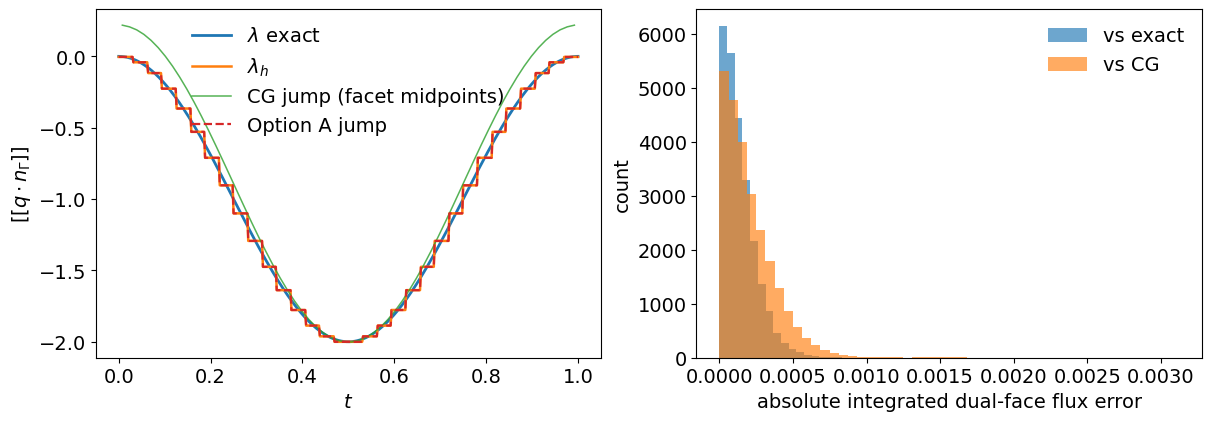

Option A analytic-trace jump check: PASS, max|jump-lambda_h|=0.000e+00
Option A completed: all construction gates passed before Option B.


In [14]:
hardcurl.plot_option_a_verification(problem, option_A)
option_A_audit = option_A["audit"]
print("Option A completed: all construction gates passed before Option B.")

# Option B — two subdomain stream functions

\(q_B^\pm=q_{p,f}+\nabla^\perp\psi_\pm\). No \(q_{p,\lambda}\) is used. The multiplier is imposed only through the difference constraint \((q_B^+-q_B^-)\cdot n_\Gamma=\lambda_h\); it is never split 50/50. Each cut data face contributes its one-sided segments. The corner-to-corner geometry has no artificial extension, so that term is reported as N/A.

## B1–B2. Penalty sweep and training

In [15]:
option_B = hardcurl.run_option_b(
    problem, penalty_weights=B_PENALTY_WEIGHTS,
    adam_steps=ADAM_STEPS_B, lbfgs_steps=LBFGS_STEPS_B,
    width=24, depth=2, lr=2.0e-3,
)

Option B penalty=1: two width=24, depth=2 networks, parameters=1970
  Adam     1/2000: loss=9.080555e+00
  Adam   250/2000: loss=9.289217e-02
  Adam   500/2000: loss=2.220892e-02
  Adam   750/2000: loss=1.280247e-02
  Adam  1000/2000: loss=1.074201e-02
  Adam  1250/2000: loss=7.642138e-03
  Adam  1500/2000: loss=5.367161e-03
  Adam  1750/2000: loss=4.751787e-03
  Adam  2000/2000: loss=4.081341e-03
  L-BFGS final: loss=2.452350e-03
Option B conservation audit, penalty=1
  RHS             class                    n       RMSE        max|R|
  lambda_h        interior-away            3906   3.538e-17   8.986e-16
  lambda_h        fracture-cut               63   2.037e-04   6.387e-04
  lambda_h        fracture-adjacent           0          N/A          N/A
  lambda_h        boundary                  256   2.449e-05   2.879e-04
  lambda_h        source                      0          N/A          N/A
  exact_lambda    interior-away            3906   3.538e-17   8.986e-16
  exact_lambda    fr

## B3. Verification battery and penalty floor

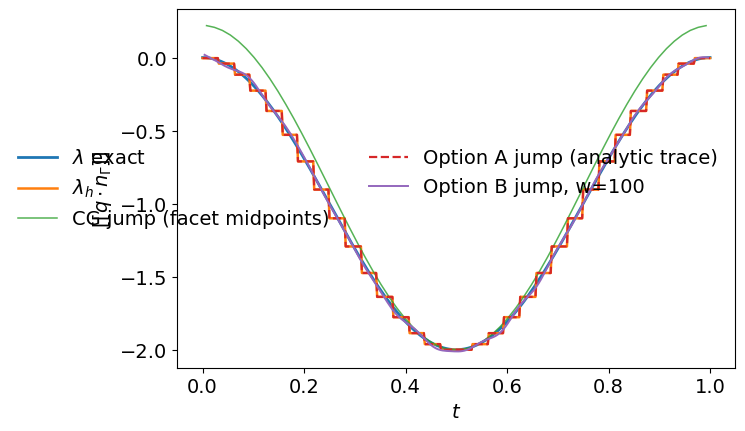

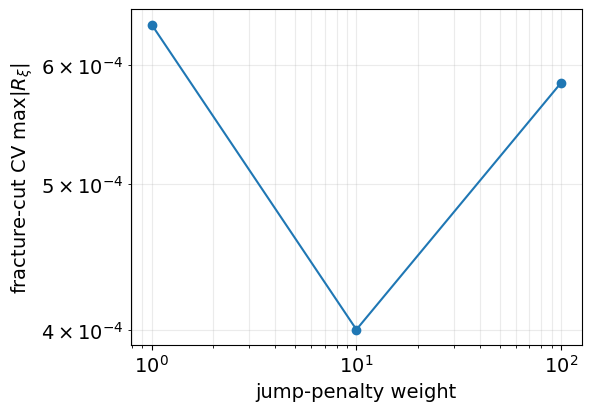

In [16]:
hardcurl.plot_verification(problem, option_A, option_B)

## Final A/B comparison

The table reports measured accuracy, conservation, parameter count, and wall time without ranking beyond the numerical evidence.

In [17]:
comparison_rows = hardcurl.comparison_table(problem, option_A, option_B)

Final Option A/B comparison
  option       flux RMSE exact   flux RMSE CG   jump RMSE lambda_h   worst class             max|R|      params    wall(s)
  A                 1.8267e-04     2.7476e-04         0.0000e+00 interior-away           8.882e-16      5665    154.63
  B(w=100)          5.0028e-03     5.0098e-03         4.0887e-02 fracture-cut            5.843e-04      1970    107.60


In [18]:
import json as _json
SUMMARY_DIR = pathlib.Path("result_fracture_MMS_hardcurl_AB")
SUMMARY_DIR.mkdir(exist_ok=True)
mesh_summary = {
    "mesh": VARIANT,
    "A_flux_error": comparison_rows[0]["face_flux_RMSE_exact"],
    "B_flux_error": comparison_rows[1]["face_flux_RMSE_exact"],
    "A_worst_Rxi": comparison_rows[0]["worst_Rxi"],
    "B_worst_Rxi": comparison_rows[1]["worst_Rxi"],
    "A_jump_error": comparison_rows[0]["jump_RMSE_lambda_h"],
    "B_jump_error": comparison_rows[1]["jump_RMSE_lambda_h"],
}
summary_file = SUMMARY_DIR / f"{VARIANT}_summary.json"
summary_file.write_text(_json.dumps(mesh_summary, indent=2) + "\n")
print("Saved", summary_file)

Saved result_fracture_MMS_hardcurl_AB/conforming_tri_summary.json


### Conclusion

Option A is conservative by construction with the discrete multiplier-consistent RHS: its line-source particular field carries the exchange distribution and its curl correction cannot change any closed-CV balance. Option B reaches only the penalty-controlled conservation floor shown above; its two smaller networks trade exact jump enforcement for a soft interface constraint. The measured flux errors, parameter counts, and wall times are reported in the table.